In [37]:
import os 
import sys 
import re 
import yaml
import inspect 
import numpy as np 
import pandas as pd
import xarray as xr
from collections import defaultdict
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl

In [ ]:
dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'
ozone_saved_filepath = dirpath + 'Plotting/USOS_Campaign_analysis/all_ozone_during_usos_with_exceedances.csv'

In [39]:
df_all_o3_load = pd.read_csv(ozone_saved_filepath, index_col='dt', parse_dates=True)
#adds padding of NaNs for first day and last day of campaign, since they need to have the same length of time as the other days in order to plot
new_start_time = pd.Timestamp('2024-07-15 00:00:00')
new_end_time = pd.Timestamp('2024-08-18 23:00:00')
# Create a new datetime index from new_start to the end of existing index with same frequency
new_index = pd.date_range(start=new_start_time, end=new_end_time, freq='1h')
# Reindex the dataframe to include new rows
df_all_o3_load = df_all_o3_load.reindex(new_index)



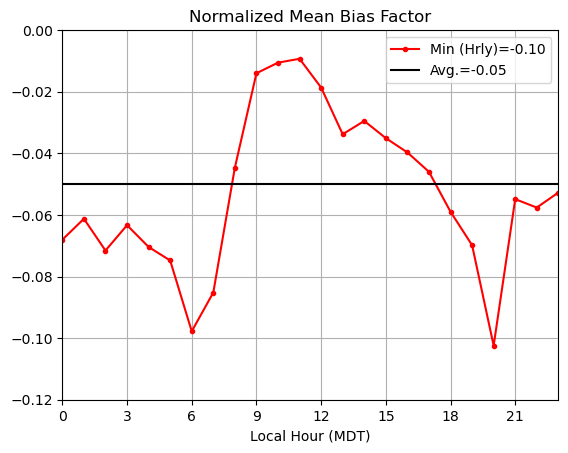

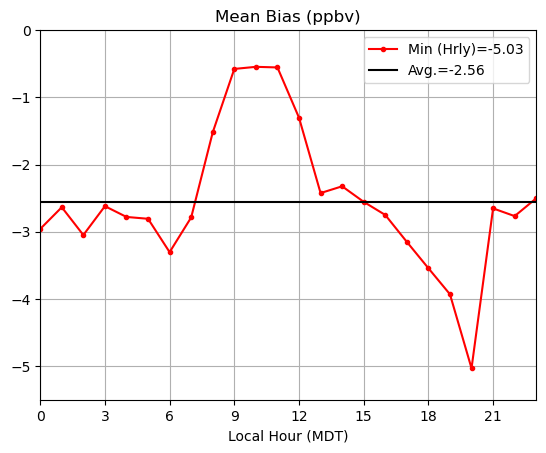

/uufs/chpc.utah.edu/common/home/u1545774/MySoftware/micromamba/envs/phdresearch/lib/python3.12/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/uufs/chpc.utah.edu/common/home/u1545774/MySoftware/micromamba/envs/phdresearch/lib/python3.12/site-packages/matplotlib/cbook.py:1398: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


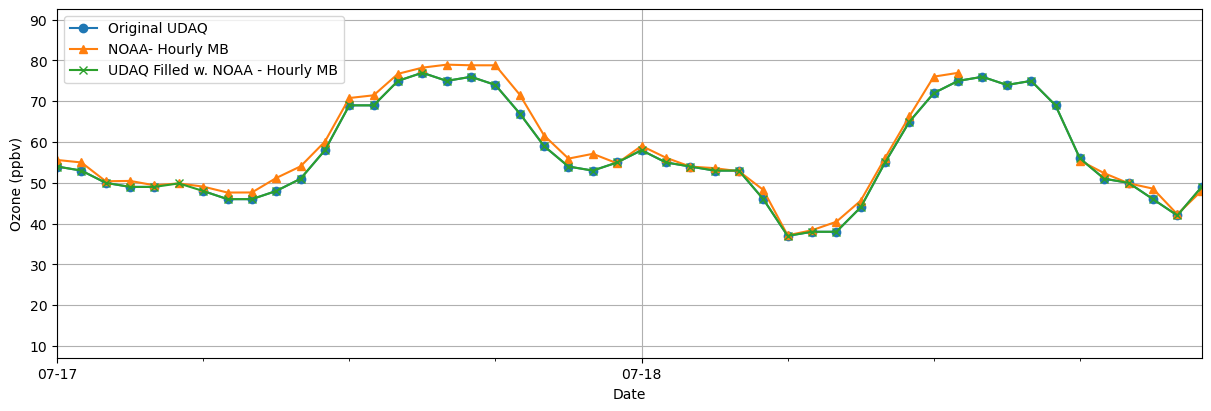

In [97]:
ddd=df_all_o3_load.copy()



ddd['hour']=ddd.index.hour 
m='UDAQ O3'
o='Mobile Lab O3'

ddd['O3_diff']= ddd[m]-ddd[o]

# NMBF mean over whole time series / all hours:  (unitless, interpret as %)
all_NMBF=np.nansum(ddd['O3_diff'])/np.nansum(ddd[m])

# Repeat, but calculate NMBF in each hour seperately: 
sum_hrly_diff=ddd.groupby('hour')['O3_diff'].apply(np.nansum)
sum_hrly_m=ddd.groupby('hour')[m].apply(np.nansum)
hrly_NMBF=sum_hrly_diff/sum_hrly_m

# Plot the hourly NMBF and the average over time: 
plt.figure()
plt.plot(hrly_NMBF.index,hrly_NMBF, color='r', marker='.', label=f"Min (Hrly)={np.min(hrly_NMBF):0.2f}" )
plt.plot(hrly_NMBF.index, np.ones(len(hrly_NMBF.index))*all_NMBF, color='k',label=f"Avg.={all_NMBF:0.2f}",)
plt.ylim([-0.12, 0])
plt.title('Normalized Mean Bias Factor')
plt.xlabel('Local Hour (MDT)')
plt.xlim([0, 23])
plt.xticks([0,3,6,9,12,15,18,21])
plt.grid()
plt.legend()

plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/normalized_mean_bias_factor_hawthorne.png', dpi =150)
plt.show()

plt.figure()
# Mean Bias: (units of [O3] Conc)
all_MB=np.nansum(ddd['O3_diff'])/ddd['O3_diff'].count()
sum_hrly_diff=ddd.groupby('hour')['O3_diff'].apply(np.nansum)
sum_hrly_n=ddd.groupby('hour')['O3_diff'].count()
hrly_MB=sum_hrly_diff/sum_hrly_n
# Plot the hourly MB and the average over time: 
plt.plot(hrly_MB.index,hrly_MB, color='r', marker='.', label=f"Min (Hrly)={np.min(hrly_MB):0.2f}" )
plt.plot(hrly_MB.index, np.ones(len(hrly_MB.index))*all_MB, label=f"Avg.={all_MB:0.2f}", color='k')
plt.ylim([-5.5, 0])
plt.xlim([0, 23])
plt.grid()
plt.xticks([0,3,6,9,12,15,18,21])
plt.xlabel('Local Hour (MDT)')
plt.title('Mean Bias (ppbv)')
plt.legend()
plt.savefig(dirpath + '/Plotting/USOS_Campaign_analysis/plots/mean_bias_hawthorne.png', dpi =150)
plt.show()


# Adjust UDAQ [O3] up by hourly bias so it's more lke what NOAA would measure: 
udaq_hrly_adj=[]
mb_dict={hr:np.abs(mb) for hr,mb in enumerate(hrly_MB)}
for t in ddd.index: 
    hr_i=t.hour
    udaq_hrly_adj.append(ddd[ddd.index==t][m]+ mb_dict[hr_i])
ddd['UDAQ_hrly_adj_O3']= udaq_hrly_adj 
udaq_avg_adj= ddd[m]+abs(all_MB)

# Fill NOAA O3 holes with UDAQ adjusted data 
ddd['NOAA_newfill']=ddd[o].fillna(ddd['UDAQ_hrly_adj_O3'])

# Adjust NOAA [O3] down by hourly bias so it's more lke what UDAQ would measure: 
noaa_hrly_adj=[]
for t in ddd.index: 
    hr_i=t.hour
    noaa_hrly_adj.append(ddd[ddd.index==t][o]- mb_dict[hr_i])
ddd['NOAA_hrly_adj_O3']= noaa_hrly_adj 
noaa_avg_adj= ddd[o]-abs(all_MB)

# Fill UDAQ O3 holes with NOAA adjusted data 
ddd['UDAQ_newfill']=ddd[m].fillna(ddd['NOAA_hrly_adj_O3'])

fig, ax = plt.subplots(figsize = (12,4), constrained_layout=True)
plt.plot(ddd.index, ddd[m], marker='o', label='Original UDAQ')
plt.plot(ddd.index, noaa_hrly_adj, marker='^', label='NOAA- Hourly MB')
#plt.plot(ddd.index,noaa_avg_adj, label='NOAA -  MB')
plt.plot(ddd.index, ddd['UDAQ_newfill'], marker='x', label='UDAQ Filled w. NOAA - Hourly MB')

#plt.plot(ddd.index, ddd[o], marker='o', label='Original NOAA')
#plt.plot(ddd.index, udaq_hrly_adj, marker='^', label='UDAQ + Hourly MB')
#plt.plot(ddd.index, udaq_avg_adj, label='UDAQ +  MB')
#plt.plot(ddd.index, ddd['NOAA_newfill'], marker='x', label='NOAA Filled w. UDAQ + Hourly MB')

 #Set x ticks
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# Minor ticks: every 6 hours
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))

ax.grid()
ax.set_yticks(np.arange(10,100,10))
ax.set_xlim([pd.to_datetime('2024-07-17 00:00:00'), pd.to_datetime('2024-07-18 23:00:00')])
ax.set_ylabel('Ozone (ppbv)')
ax.set_xlabel('Date')
ax.legend()
